In [1]:
#pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 64.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

# 1. Data Preparation

In [28]:
#load data
data = pd.read_csv("bank-full.csv", sep = ";")



#separate features and target
X = data.drop("y", axis = 1)
y = data["y"]
y = y.map({"yes":1, "no":0}) #target -> numbers



#split data （70/15/15）
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y,test_size = 0.3, random_state = 42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


#preprocessing
#identify column types
num_cols = X.select_dtypes(include = ["int64","float64"]).columns
cat_cols = X.select_dtypes(include = ["object"]).columns



#handle missing values
#numerical:median
num_imputer = SimpleImputer(strategy = "median")
num_imputer.fit(X_train[num_cols])
X_train_num = num_imputer.transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])

#categorical:frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[cat_cols])   # fit ONLY on training
X_train_cat = cat_imputer.transform(X_train[cat_cols])
X_val_num = num_imputer.transform(X_val[num_cols])
X_test_cat = cat_imputer.transform(X_test[cat_cols])



#encoding (for catergorical)
encoder = OneHotEncoder(handle_unknown = "ignore")
encoder.fit(X_train_cat)
X_train_cat_enc = encoder.transform(X_train_cat)
X_val_cat = cat_imputer.transform(X_val[cat_cols])
X_test_cat_enc = encoder.transform(X_test_cat)

#sparse matrix-> array
X_train_cat_enc = X_train_cat_enc.toarray()
X_val_cat_enc = encoder.transform(X_val_cat).toarray() 
X_test_cat_enc = X_test_cat_enc.toarray()



#feature scaling (for numerical)
scaler = StandardScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

#combine
X_train_mlp = np.hstack([X_train_num_scaled, X_train_cat_enc])
X_val_mlp = np.hstack([X_val_num_scaled, X_val_cat_enc])
X_test_mlp = np.hstack([X_test_num_scaled, X_test_cat_enc])

X_train_gbdt = np.hstack([X_train_num, X_train_cat_enc])
X_val_gbdt = np.hstack([X_val_num, X_test_cat_enc])
X_test_gbdt = np.hstack([X_test_num, X_test_cat_enc])

# 2. Gradient Boosted Tree (GBDT)

In [29]:
#hyperparameter tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": [0.01, 0.1,0.3],
    "max_depth": [3, 5],
    "n_estimators": [100, 200]
}

model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3, # 3-fold cross validation
    verbose=1
)

grid.fit(X_train_gbdt, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:43:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:43:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:43:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:43:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Score: 0.9075741776471703


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:43:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
start_time = time.time()

gbdt = xgb.XGBClassifier(
    learning_rate = 0.1,
    n_estimatos = 200,
    max_depth = 5,
    subsample = 0.8,
    reg_alpha = 0,
    reg_lambda = 1,
    random_state = 42,
    use_label_encoder = False,
    eval_metric = "logloss",
    early_stopping_rounds=20
)

#validation for early stopping
gbdt.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_train_gbdt, y_train),(X_val_gbdt, y_val)],
    verbose=False
)
gbdt_time = time.time() - start_time

/opt/anaconda3/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [03:43:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimatos", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [31]:
#evaluation
y_pred = gbdt.predict(X_test_gbdt)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8972279563550575


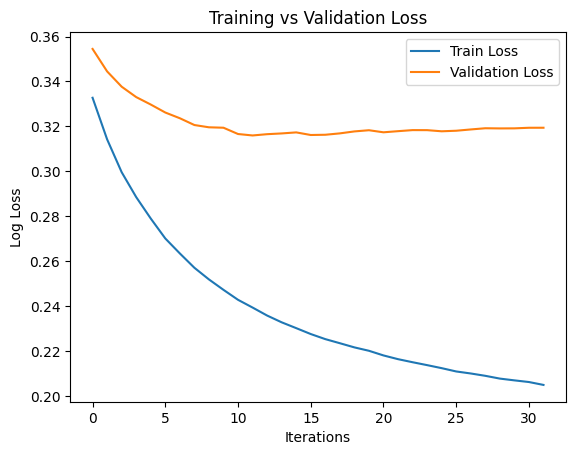

In [32]:
#visualization
#training vs. validation loss
results = gbdt.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

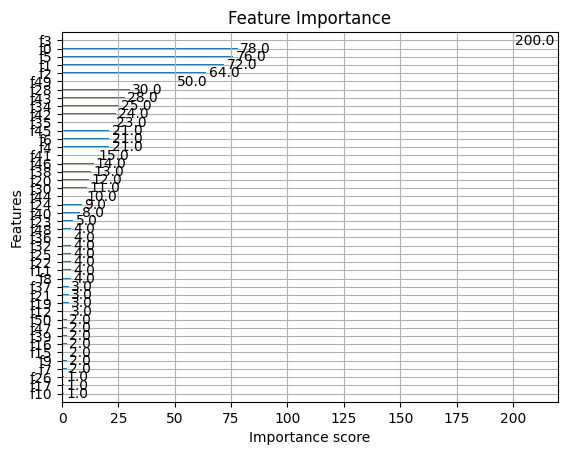

[0.02204152 0.00719681 0.00972632 0.10539449 0.01478732 0.01748416
 0.00586976 0.00610266 0.0120038  0.00309839 0.00046982 0.00376266
 0.00394908 0.         0.         0.01264248 0.00329755 0.01043314
 0.         0.0055378  0.01124562 0.01355299 0.00424816 0.00290616
 0.00807958 0.00619872 0.00028273 0.         0.04846113 0.
 0.02025903 0.         0.00781011 0.         0.10551937 0.04403069
 0.03121066 0.01626545 0.00750732 0.01025171 0.02905979 0.04504303
 0.04805973 0.01123846 0.01241356 0.04578216 0.02547488 0.00729233
 0.00068635 0.12991123 0.06341136]


In [33]:
#feature importance
xgb.plot_importance(gbdt)
plt.title("Feature Importance")
plt.show()

importances = gbdt.feature_importances_
print(importances)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:44:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Learning rate 0.01: Validation Accuracy = 0.8743733411972869
Learning rate 0.1: Validation Accuracy = 0.8569743438513713


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:44:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:44:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Learning rate 0.3: Validation Accuracy = 0.842229430846358


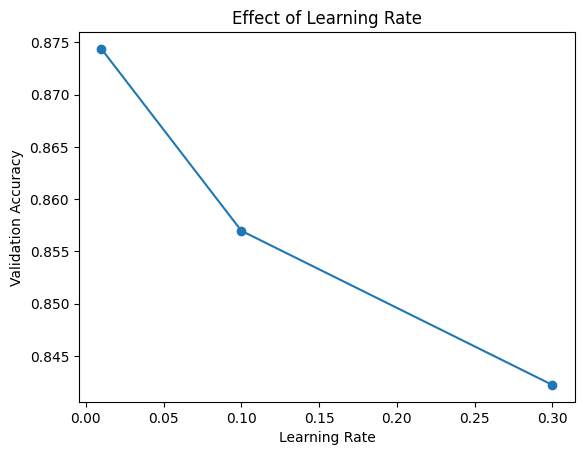

In [34]:
#effect of learning rate
learning_rates = [0.01,0.1,0.3]
results_lr = []

for lr in learning_rates:
    temp_model = xgb.XGBClassifier(
        learning_rate = lr,
        n_estimators = 200,
        max_depth = 5,
        subsample = 0.8,
        reg_alpha = 0,
        reg_lambda = 1,
        random_state = 42,
        use_label_encoder = False,
        eval_metric = "logloss"
    )
    temp_model.fit(X_train_gbdt, y_train)
    y_val_pred = temp_model.predict(X_val_gbdt)
    acc = accuracy_score(y_val, y_val_pred)
    results_lr.append(acc)

    print(f"Learning rate {lr}: Validation Accuracy = {acc}")

plt.figure()
plt.plot(learning_rates, results_lr, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Learning Rate")
plt.show()

# 3. Multi-Layer Perceptron (MLP)

In [35]:
start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation = 'relu',
    learning_rate_init = 0.001,
    max_iter=200,
    random_state=42
)

mlp.fit(X_train_mlp, y_train)
mlp_time = time.time() - start_time

In [36]:
#evaluation
y_val_pred = mlp.predict(X_val_mlp)
print("Validation Accuracy:",accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.8888233559422


In [37]:
#cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    mlp,
    X_train_mlp,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-validation scores: [0.88278041 0.87993681 0.88971401 0.8833939  0.89113604]
Mean accuracy: 0.8853922351960944


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


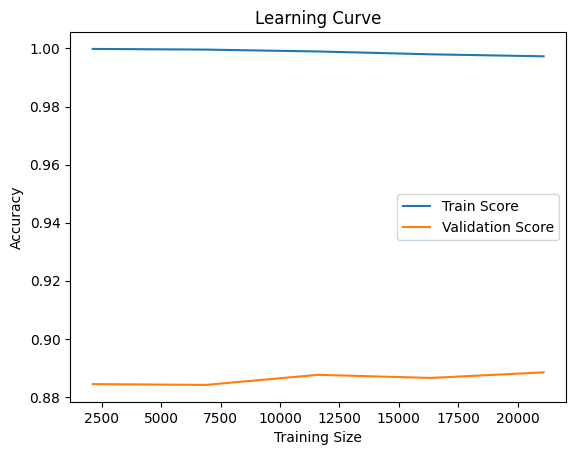

In [38]:
#learning curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    mlp,
    X_train_mlp,
    y_train,
    cv=3,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


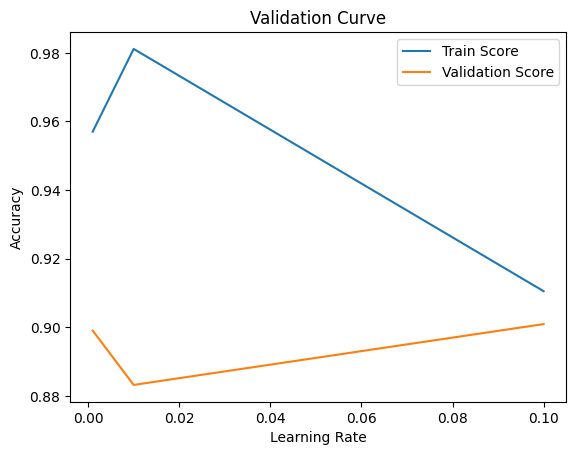

In [39]:
#validation curve
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1]

train_scores, val_scores = validation_curve(
    MLPClassifier(max_iter=200, random_state=42),
    X_train_mlp,
    y_train,
    param_name="learning_rate_init",
    param_range=param_range,
    cv=3,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(param_range, train_mean, label="Train Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
plt.legend()
plt.show()

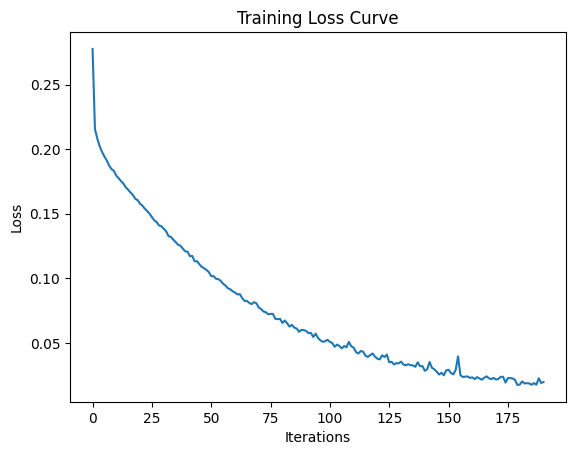

In [40]:
#visualization
#training loss curve
plt.figure()
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers (64,): Validation Accuracy = 0.8957534650545562
Layers (128, 64): Validation Accuracy = 0.8888233559422
Layers (256, 128, 64): Validation Accuracy = 0.8845473311707461


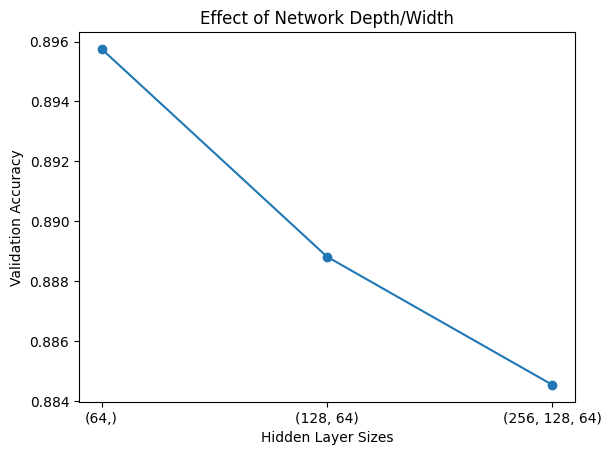

In [41]:
#effect of network depth/width
layer_options = [(64,),(128,64),(256,128,64)]
layer_results = []

for layers in layer_options:
    temp_model = MLPClassifier(
        hidden_layer_sizes = layers,
        max_iter = 200,
        random_state = 42
    )
    temp_model.fit(X_train_mlp, y_train)
    y_val_pred = temp_model.predict(X_val_mlp)
    acc = accuracy_score(y_val, y_val_pred)
    layer_results.append(acc)
    
    print(f"Layers {layers}: Validation Accuracy = {acc}")

plt.figure()
plt.plot(range(len(layer_options)),layer_results,marker = 'o')
plt.xticks(range(len(layer_options)),layer_options)
plt.xlabel("Hidden Layer Sizes")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Network Depth/Width")
plt.show()


In [23]:
#effect of activation (e.g., relu vs tanh)
activations = ["relu", "tanh"]
act_results = []

for act in activations:
    temp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        max_iter=200,
        random_state=42
    )
    temp_model.fit(X_train_mlp, y_train)
    y_val_pred = temp_model.predict(X_val_mlp)
    acc = accuracy_score(y_val, y_val_pred)
    act_results.append(acc)
    
    print(f"Activation {act}: Validation Accuracy = {acc}")

Activation relu: Validation Accuracy = 0.8888233559422
Activation tanh: Validation Accuracy = 0.8885284576820996


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
#effect of learning_rate_init (e.g., 0.001, 0.01, 0.1)
learning_rates = [0.001, 0.01, 0.1]
lr_results = []

for lr in learning_rates:
    temp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        learning_rate_init=lr,
        max_iter=200,
        random_state=42
    )
    temp_model.fit(X_train_mlp, y_train)
    y_val_pred = temp_model.predict(X_val_mlp)
    acc = accuracy_score(y_val, y_val_pred)
    lr_results.append(acc)
    
    print(f"Learning Rate {lr}: Validation Accuracy = {acc}")

Learning Rate 0.001: Validation Accuracy = 0.8888233559422
Learning Rate 0.01: Validation Accuracy = 0.8836626363904453
Learning Rate 0.1: Validation Accuracy = 0.8992922441757594


In [42]:
#effect of max_iter
iters = [100, 200, 300]
iter_results = []

for it in iters:
    temp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=it,
        random_state=42
    )
    temp_model.fit(X_train_mlp, y_train)
    y_val_pred = temp_model.predict(X_val_mlp)
    acc = accuracy_score(y_val, y_val_pred)
    iter_results.append(acc)
    
    print(f"Max_iter {it}: Validation Accuracy = {acc}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Max_iter 100: Validation Accuracy = 0.8745207903273371
Max_iter 200: Validation Accuracy = 0.8888233559422
Max_iter 300: Validation Accuracy = 0.8888233559422


# 4. GBDT vs MLP Comparison

In [43]:
#predictions
# MLP
mlp_pred = mlp.predict(X_test_mlp)
mlp_prob = mlp.predict_proba(X_test_mlp)[:, 1]
# GBDT
gbdt_pred = gbdt.predict(X_test_gbdt)
gbdt_prob = gbdt.predict_proba(X_test_gbdt)[:, 1]



#metrics
def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_prob)
    }

mlp_metrics = get_metrics(y_test, mlp_pred, mlp_prob)
gbdt_metrics = get_metrics(y_test, gbdt_pred, gbdt_prob)



#comparison table
comparison = pd.DataFrame([mlp_metrics, gbdt_metrics],
                          index=["MLP", "GBDT"])
comparison["Training Time (s)"] = [mlp_time, gbdt_time]
print("\n=== Comparison Table ===")
print(comparison)


=== Comparison Table ===
      Accuracy  Precision    Recall  F1-score    AUC-PR  Training Time (s)
MLP   0.890445   0.523743  0.482625  0.502344  0.492815          32.442478
GBDT  0.897228   0.750000  0.154440  0.256137  0.558097           0.065105
